In [88]:
import numpy as np
import pandas as pd

пункт а

In [89]:
np.random.seed(42)
n = 50
x = np.random.uniform(-1, 1, size=(n, 5))


In [90]:
def mnk_coef(A, y):
    return np.linalg.inv(A.T @ A) @ A.T @ y


def get_r2(y, y_hat):
    rss = np.sum((y - y_hat) ** 2)
    tss = np.sum((y - np.mean(y)) ** 2)

    return 1 - rss / tss


In [91]:
for k in range(5):
    y = x[:, k]

    cols = [i for i in range(5) if i != k]

    A = x[:, cols]
    A = np.column_stack((np.ones(n), A))

    beta = mnk_coef(A, y)

    y_hat = A @ beta

    R2 = get_r2(y, y_hat)

    print(f'x{k + 1}: R^2 = {R2:.4f}')

    if R2 > 0.7:
        print('Есть мультиколлинеарность')
    else:
        print('Мультиколлинеарности нет')


x1: R^2 = 0.1172
Мультиколлинеарности нет
x2: R^2 = 0.1139
Мультиколлинеарности нет
x3: R^2 = 0.1429
Мультиколлинеарности нет
x4: R^2 = 0.0461
Мультиколлинеарности нет
x5: R^2 = 0.1000
Мультиколлинеарности нет


пункт b

In [92]:
from scipy import stats

In [93]:

eps = np.random.normal(0, 1.5, size=n)

y = 2 + 3*x[:, 0] - 2*x[:, 1] + x[:, 2] + x[:, 3] - x[:, 4] + eps

X = np.column_stack((np.ones(n), x))

p = X.shape[1]

F = X.T @ X
F_inv = np.linalg.inv(F)

beta = F_inv @ X.T @ y

y_hat = X @ beta
ost = y - y_hat

rss = np.sum(ost ** 2)

alpha = 0.05

names = ['beta0', 'beta1', 'beta2', 'beta3', 'beta4', 'beta5']

print('Уравнение регрессии:')
print(f'y = {beta[0]:.4f} + ({beta[1]:.4f})x1 + ({beta[2]:.4f})x2 + ({beta[3]:.4f})x3 + ({beta[4]:.4f})x4 + ({beta[5]:.4f})x5')
print()

for i in range(p):
    delta = abs(beta[i]) * np.sqrt(n - p) / np.sqrt(F_inv[i, i] * rss)

    p_value = 2 * (1 - stats.t.cdf(delta, df=n - p))

    print(names[i])
    print('coef =', beta[i])
    print('delta =', delta)
    print('p-value =', p_value)

    if p_value < alpha:
        print('коэффициент значим')
    else:
        print('коэффициент не значим')


Уравнение регрессии:
y = 2.0699 + (2.7552)x1 + (-2.1409)x2 + (1.0096)x3 + (0.7684)x4 + (-1.2105)x5

beta0
coef = 2.0699044106439626
delta = 8.390424661982443
p-value = 1.1171308322843743e-10
коэффициент значим
beta1
coef = 2.7551697250067524
delta = 6.320769440544633
p-value = 1.1386536558077864e-07
коэффициент значим
beta2
coef = -2.1409204420128534
delta = 4.788384224390643
p-value = 1.933162673384281e-05
коэффициент значим
beta3
coef = 1.0096160496557554
delta = 2.3143501414889167
p-value = 0.025378054152101592
коэффициент значим
beta4
coef = 0.7683526281707025
delta = 1.8711276445969203
p-value = 0.0679862752874012
коэффициент не значим
beta5
coef = -1.2104888881099156
delta = 2.779994410809928
p-value = 0.007968311477182466
коэффициент значим


пункт с

In [94]:
tss = np.sum((y - np.mean(y)) ** 2)

R2 = 1 - rss / tss

delta = (R2 * (n - p)) / ((1 - R2) * (p - 1))

p_value = 1 - stats.f.cdf(delta, dfn=p - 1, dfd=n - p)

print('R^2 =', R2)
print('delta =', delta)
print('p-value =', p_value)

if p_value < alpha:
    print('Коэффициент детерминации значим')
else:
    print('Коэффициент детерминации не значим')

R^2 = 0.6263847372343578
delta = 14.753641612120061
p-value = 1.703381657947034e-08
Коэффициент детерминации значим


пункт d

In [95]:
gamma = 0.95

psi_0 = np.array([1, 0, 0, 0, 0, 0])

y_prog = psi_0 @ beta

delta_interval = stats.t.ppf((1 + gamma) / 2, df=n - p) * np.sqrt(
    rss * (1 + psi_0 @ F_inv @ psi_0.T) / (n - p)
)

print(f'y_prog = {y_prog}')
print(f'Доверительный интервал для y_prog: [{y_prog - delta_interval}, {y_prog + delta_interval}]')

y_prog = 2.0699044106439626
Доверительный интервал для y_prog: [-1.4231622630038632, 5.562971084291789]


пункт е

In [96]:
def inversions_count(arr):
    inv = 0

    for i in range(len(arr)):
        for j in range(i + 1, len(arr)):
            if arr[i] > arr[j]:
                inv += 1

    return inv

E = y - y_hat
I = inversions_count(E)
delta = (
    I - n * (n - 1) / 4
) / np.sqrt(n**3 / 36)
p_value = 2 * (1 - stats.norm.cdf(abs(delta)))

print('I =', I)
print('delta =', delta)
print('p-value =', p_value)

if p_value < alpha:
    print('Отвергаем H0, ошибки зависимы')
else:
    print('нет оснований отвергнуть H0: ошибки независимы')

I = 579
delta = -0.5685138520739842
p-value = 0.5696861025625761
нет оснований отвергнуть H0: ошибки независимы


пункт f

In [97]:
def sample_sigma(arr):
    return np.sqrt(
        np.sum((arr - np.mean(arr)) ** 2) / (len(arr) - 1)
    )


def kolmogorov_delta(sorted_arr, sigma):
    F_emp = np.arange(0, n + 1) / n

    F_norm = stats.norm.cdf(
        sorted_arr,
        loc=0,
        scale=sigma
    )

    delta = np.sqrt(n) * np.max(
        np.maximum(
            np.abs(F_norm - F_emp[1:]),
            np.abs(F_norm - F_emp[:-1])
        )
    )

    return float(delta)


def bootstrap_pvalue(delta_obs, sigma, N):
    vals = []

    for _ in range(N):

        sample = np.sort(
            stats.norm.rvs(
                loc=0,
                scale=sigma,
                size=n
            )
        )

        sigma_star = sample_sigma(sample)

        vals.append(
            kolmogorov_delta(sample, sigma_star)
        )

    vals = np.array(vals)

    return np.sum(vals > delta_obs) / N


errors = np.sort(E)

sigma_hat = sample_sigma(errors)

delta_obs = kolmogorov_delta(errors, sigma_hat)

N = 50000

p_value = bootstrap_pvalue(
    delta_obs,
    sigma_hat,
    N
)

print('Статистика Колмогорова =', delta_obs)
print('p-value =', p_value)

if p_value < alpha:
    print('Отвергаем H0')
    print('Распределение ошибок не является нормальным')
else:
    print('Нет оснований отвергнуть H0')
    print('Данные не противоречат нормальности ошибок')

Статистика Колмогорова = 0.8002463355687731
p-value = 0.44668
Нет оснований отвергнуть H0
Данные не противоречат нормальности ошибок


пункт g

In [98]:
import matplotlib.pyplot as plt

Q1 = -1.1255383207183045
Q3 = 0.7724079199216124
IQR = 1.897946240639917
Левая граница = -3.97245768167818
Правая граница = 3.619327280881488
Количество выбросов = 1
Выбросы:
[5.25253014]


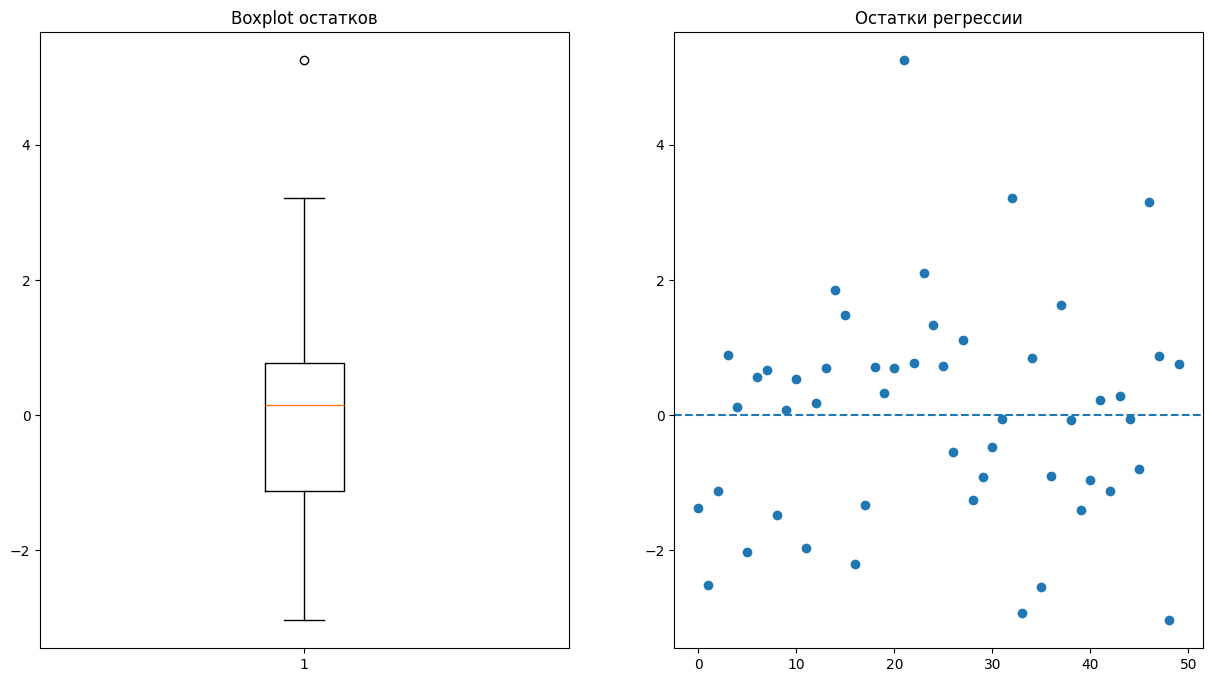

In [99]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].boxplot(E)
ax[0].set_title('Boxplot остатков')


ax[1].scatter(np.arange(len(E)), E)

ax[1].axhline(
    0,
    linestyle='--'
)

ax[1].set_title('Остатки регрессии')


q1 = np.percentile(E, 25)
q3 = np.percentile(E, 75)

iqr = q3 - q1

left = q1 - 1.5 * iqr
right = q3 + 1.5 * iqr

outliers = E[(E < left) | (E > right)]

print('Q1 =', q1)
print('Q3 =', q3)

print('IQR =', iqr)

print('Левая граница =', left)
print('Правая граница =', right)

print('Количество выбросов =', len(outliers))

if len(outliers) > 0:
    print('Выбросы:')
    print(outliers)
else:
    print('Выбросов не обнаружено')

plt.show()

пункт h

In [100]:
def tss(y):
    return np.sum(
        (y - np.mean(y)) ** 2
    )


def mnk_solution(A, b):
    return np.linalg.inv(
        A.T @ A
    ) @ A.T @ b


def predict_value(x_row, beta):
    return x_row @ beta

In [101]:

tss = tss(y)
cvss = 0

for k in range(n):

    X_new = np.delete(X, k, axis=0)
    y_new = np.delete(y, k)

    beta_new = mnk_solution(X_new, y_new)

    y_k_hat = predict_value(
        X[k],
        beta_new
    )

    cvss += (y[k] - y_k_hat) ** 2

R2_cv = 1 - cvss / tss
print('CVSS =', cvss)
print('R^2_cv =', R2_cv)

CVSS = 166.0420502905386
R^2_cv = 0.5209578621563502


пункт i

In [102]:
m = 5
psi = np.array([1, 0, 0, 0, 0, 0])
mean_y = 2 + 3*psi[1] - 2*psi[2] + psi[3] + psi[4] - psi[5]

y_repeat = stats.norm(
    loc=mean_y,
    scale=1.5
).rvs(m)

s2_repeat = np.var(y_repeat, ddof=1)

delta_adeq = rss / ((n - p) * s2_repeat)

p_value_adeq = 1 - stats.f.cdf(
    delta_adeq,
    dfn=n - p,
    dfd=m - 1
)

print('Повторные измерения:', y_repeat)
print('S^2 =', s2_repeat)
print('delta =', delta_adeq)
print('p-value =', p_value_adeq)

if p_value_adeq < alpha:
    print('Отвергаем H0: есть основания считать модель неадекватной')
else:
    print('Нет оснований отвергнуть H0: данные не противоречат адекватности модели')

Повторные измерения: [4.75183886 3.0808319  0.13832244 1.71534844 4.01529637]
S^2 = 3.4021698035938246
delta = 0.8650880602464434
p-value = 0.656814245996496
Нет оснований отвергнуть H0: данные не противоречат адекватности модели


пункт j

In [103]:
X_short = np.delete(X, 4, axis=1)

n_short, p_short = X_short.shape

F_short = X_short.T @ X_short
F_inv_short = np.linalg.inv(F_short)

beta_short = F_inv_short @ X_short.T @ y

y_hat_short = X_short @ beta_short

rss_short = np.sum((y - y_hat_short) ** 2)

tss = np.sum((y - np.mean(y)) ** 2)

R2_short = 1 - rss_short / tss

print('Уравнение короткой регрессии без x4:')
print(
    f'y = {beta_short[0]:.3f} '
    f'+ ({beta_short[1]:.3f})x1 '
    f'+ ({beta_short[2]:.3f})x2 '
    f'+ ({beta_short[3]:.3f})x3 '
    f'+ ({beta_short[4]:.3f})x5'
)


print('Проверка значимости коэффициентов:')

names_short = ['beta0', 'beta1', 'beta2', 'beta3', 'beta5']

for i in range(p_short):
    delta_i = abs(beta_short[i]) * np.sqrt(n_short - p_short) / np.sqrt(
        F_inv_short[i, i] * rss_short
    )

    p_value_i = 2 * (1 - stats.t.cdf(delta_i, df=n_short - p_short))

    print(names_short[i])
    print('delta =', delta_i)
    print('p-value =', p_value_i)

    if p_value_i < alpha:
        print('коэффициент значим')
    else:
        print('коэффициент не значим')



Уравнение короткой регрессии без x4:
y = 2.071 + (2.749)x1 + (-2.072)x2 + (0.976)x3 + (-1.039)x5
Проверка значимости коэффициентов:
beta0
delta = 8.172469948752312
p-value = 1.9365153924866263e-10
коэффициент значим
beta1
delta = 6.137807992307603
p-value = 1.948891281688958e-07
коэффициент значим
beta2
delta = 4.525894029127468
p-value = 4.376732278643658e-05
коэффициент значим
beta3
delta = 2.1796551185417092
p-value = 0.03455585500606517
коэффициент значим
beta5
delta = 2.375735750622354
p-value = 0.021832779776375544
коэффициент значим


In [104]:
# повтор пункта c 
delta_F_short = R2_short * (n_short - p_short) / (
    (1 - R2_short) * (p_short - 1)
)

p_value_F_short = 1 - stats.f.cdf(
    delta_F_short,
    dfn=p_short - 1,
    dfd=n_short - p_short
)

print('R^2_short =', R2_short)
print('delta_F =', delta_F_short)
print('p-value =', p_value_F_short)

if p_value_F_short < alpha:
    print('Коэффициент детерминации значим')
else:
    print('нет оснований считать, что коэффициент детерминации значим')

R^2_short = 0.5966558424839746
delta_F = 16.64181345598894
p-value = 1.9355898106532266e-08
Коэффициент детерминации значим


In [105]:
# сравнение полной и короткой регрессии
p_full = p
p_reduced = p_short

rss_full = rss
rss_reduced = rss_short

delta_compare = (
    (rss_reduced - rss_full) * (n - p_full)
) / (
    rss_full * (p_full - p_reduced)
)

p_value_compare = 1 - stats.f.cdf(
    delta_compare,
    dfn=p_full - p_reduced,
    dfd=n - p_full
)

print('Сравнение регрессий:')
print('delta =', delta_compare)
print('p-value =', p_value_compare)

if p_value_compare < alpha:
    print('Усложнение регрессии значимо')
else:
    print('Усложнение регрессии не значимо')

Сравнение регрессий:
delta = 3.5011186623748096
p-value = 0.06798627528740153
Усложнение регрессии не значимо


пункт k

In [106]:
data = np.column_stack((X, y))

N_bs = 1000

h = rss_short - rss


def get_bootstrap_deltas(data, N_bs):
    vals = []

    for _ in range(N_bs):
        ind = np.random.choice(
            data.shape[0],
            size=data.shape[0],
            replace=True
        )

        cur_data = data[ind]

        X_cur = cur_data[:, :-1]
        y_cur = cur_data[:, -1]

        F_cur = X_cur.T @ X_cur
        F_cur_inv = np.linalg.inv(F_cur)

        beta_full_cur = F_cur_inv @ X_cur.T @ y_cur
        y_full_cur = X_cur @ beta_full_cur

        rss_full_cur = np.sum((y_cur - y_full_cur) ** 2)

        X_cur_short = np.delete(X_cur, 4, axis=1)

        F_cur_short = X_cur_short.T @ X_cur_short
        F_cur_short_inv = np.linalg.inv(F_cur_short)

        beta_short_cur = F_cur_short_inv @ X_cur_short.T @ y_cur
        y_short_cur = X_cur_short @ beta_short_cur

        rss_short_cur = np.sum((y_cur - y_short_cur) ** 2)

        h_cur = rss_short_cur - rss_full_cur

        vals.append(h_cur - h)

    return np.sort(np.array(vals))


deltas = get_bootstrap_deltas(data, N_bs)

ci_left = h - deltas[N_bs - 1]
ci_right = h - deltas[int(0.05 * N_bs)]

print(f'h = {h:.3f}')
print(f'Доверительный интервал для h: [{ci_left:.3f}, {ci_right:.3f}]')

if ci_left < 0 < ci_right:
    print('Ноль входит в доверительный интервал')
    print('Нет оснований считать различие между полной и короткой регрессией значимым')
else:
    print('Ноль не входит в доверительный интервал')
    print('Есть основания считать различие между полной и короткой регрессией значимым')

h = 10.304
Доверительный интервал для h: [-48.318, 20.250]
Ноль входит в доверительный интервал
Нет оснований считать различие между полной и короткой регрессией значимым
